# Load and Data Analysis

Importing Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

Load the dataset

In [2]:
from sklearn.datasets import fetch_openml
housing = fetch_openml(data_id=531)

In [3]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
housing.feature_names

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

In [5]:
housing.target_names

['MEDV']

In [6]:
X = housing.data
y = housing.target

In [7]:
# Converting into pandas dataframe
df = pd.DataFrame(X,columns=housing.feature_names)
df[housing.target_names[0]] = y

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [9]:
# Drop categorical variables
category=[]
for i in df.columns:
  if df[i].dtype == 'category':
    category.append(i)
df.drop(category, inplace=True,axis=1)

In [10]:
df.head()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,222.0,18.7,396.90,5.33,36.2



Data Profiling

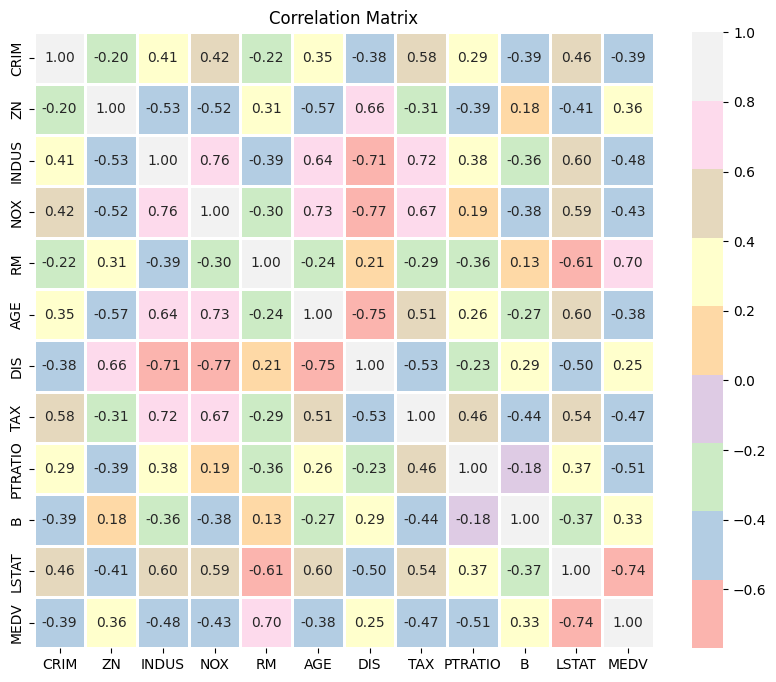

In [11]:
# Correlation Heatmap

# Compute covariance matrix
corr_matrix = df.corr()
# Create the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='Pastel1', fmt='.2f', linewidths=1)
# Add titles and labels
plt.title('Correlation Matrix')
plt.show()

<Figure size 1200x1000 with 0 Axes>

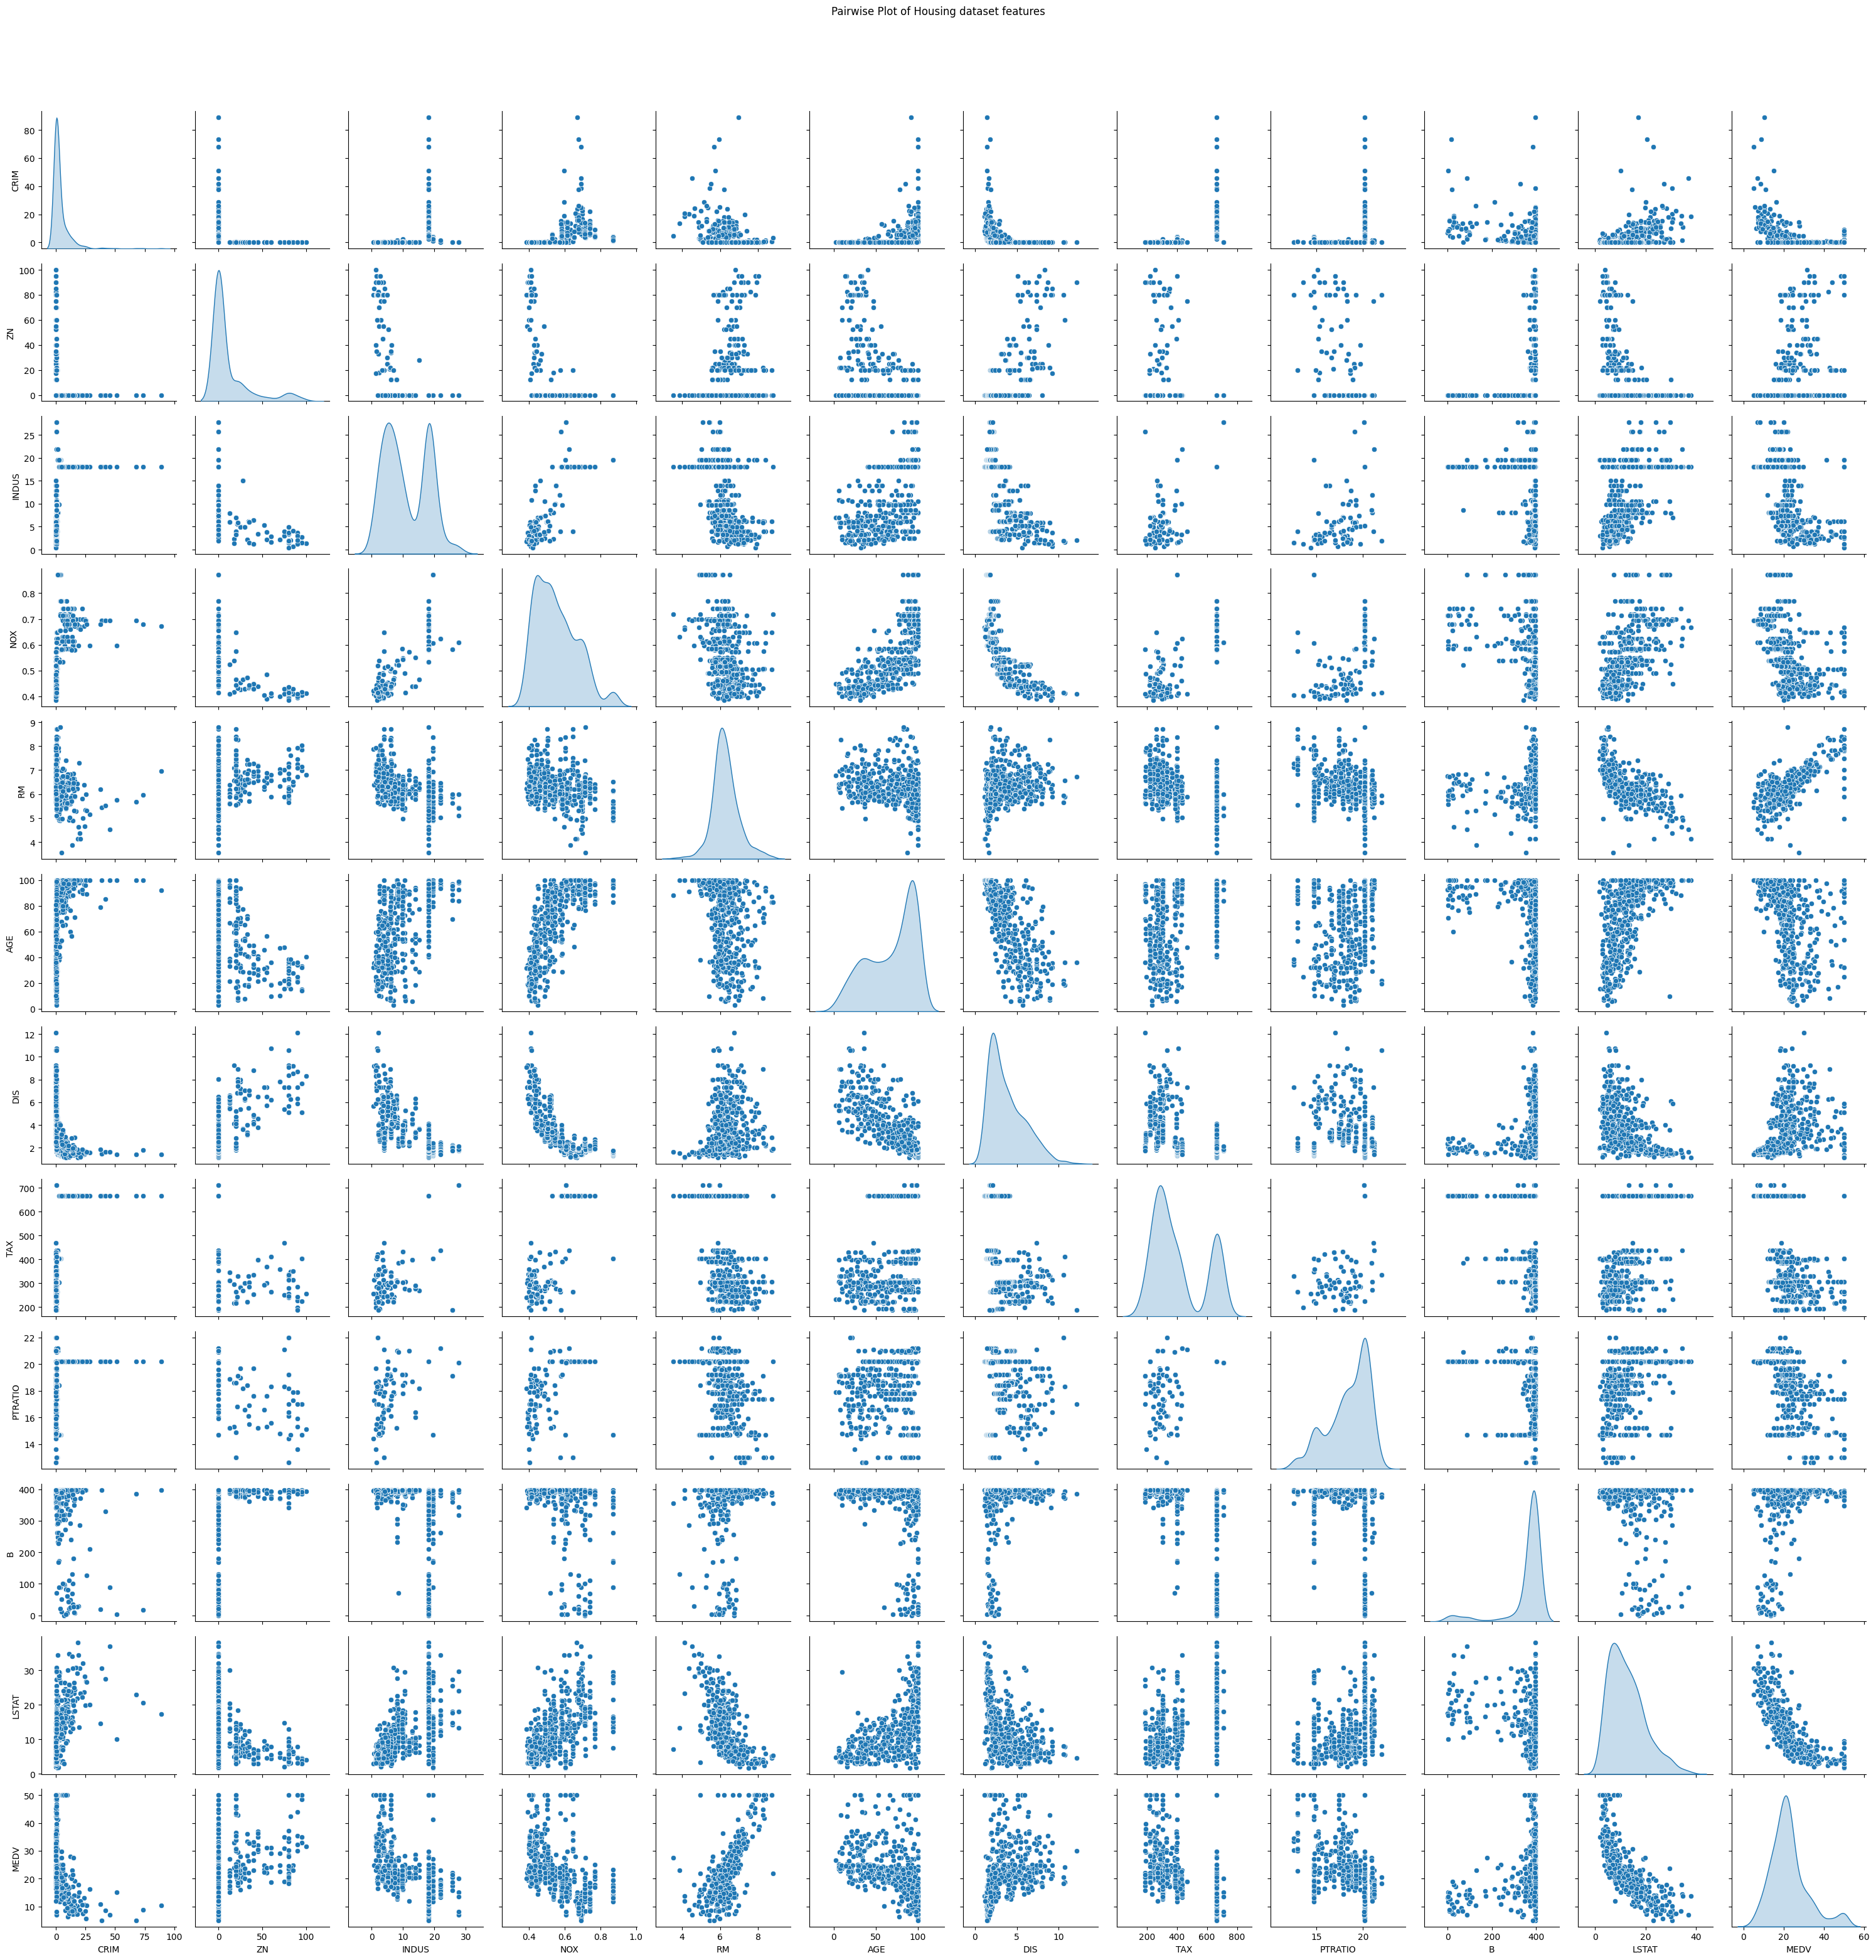

In [12]:
# Pairplot of features

plt.figure(figsize=(12,10))
pairplot = sns.pairplot(df, diag_kind='kde',corner=False,height=2.5)

pairplot.fig.suptitle("Pairwise Plot of Housing dataset features", y=1.04)
plt.tight_layout()
plt.show()

Feature vs Target (Scatter plots)

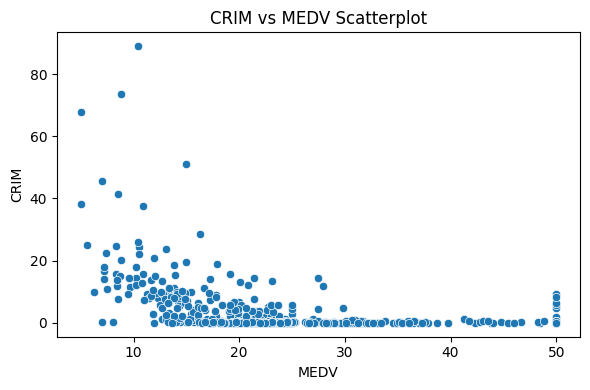

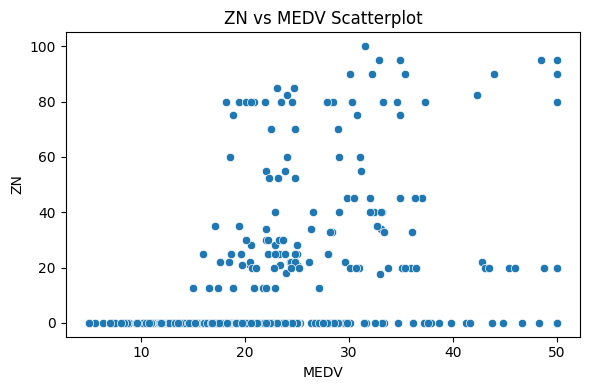

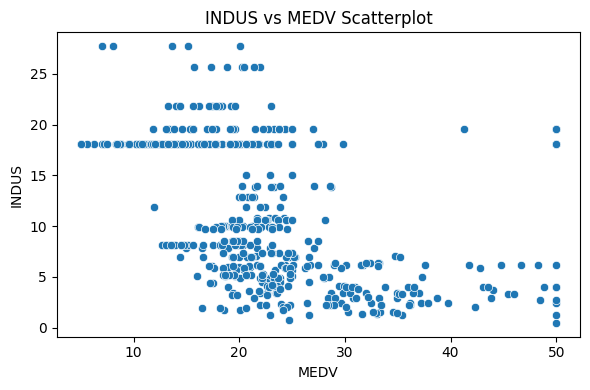

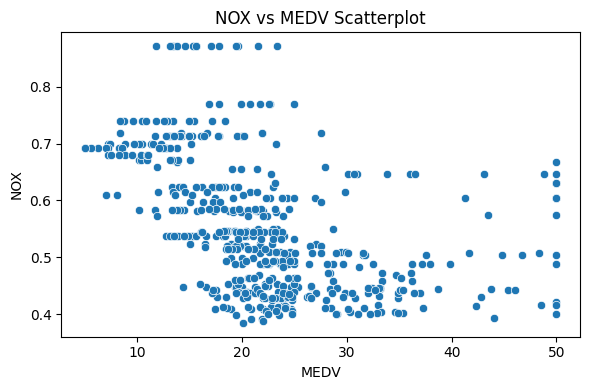

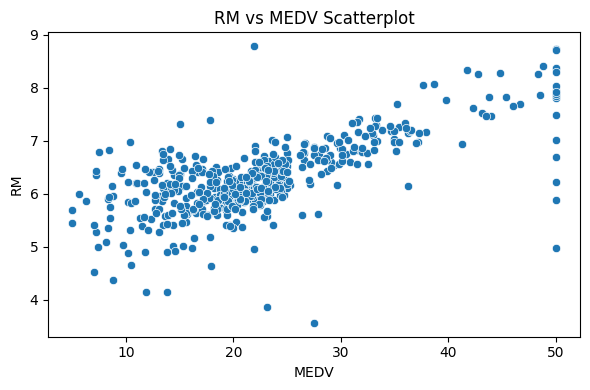

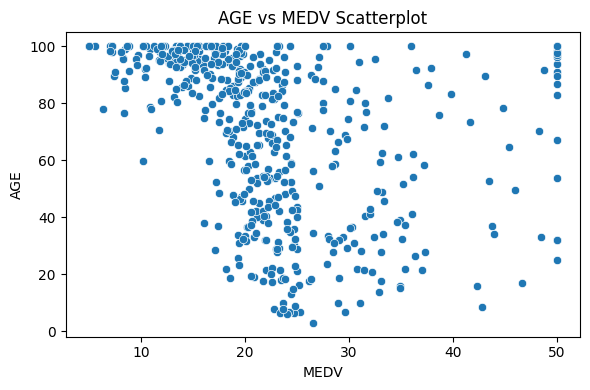

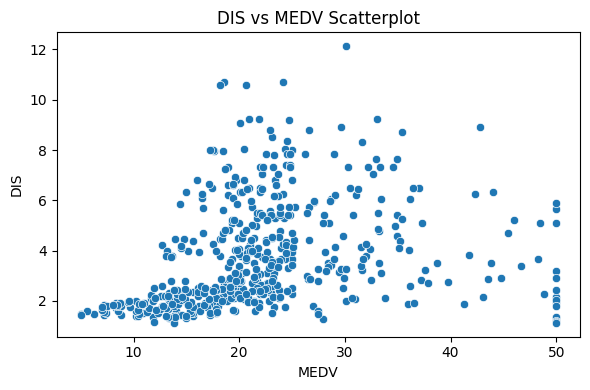

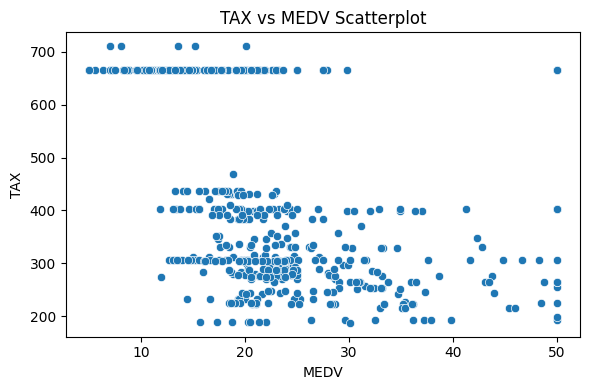

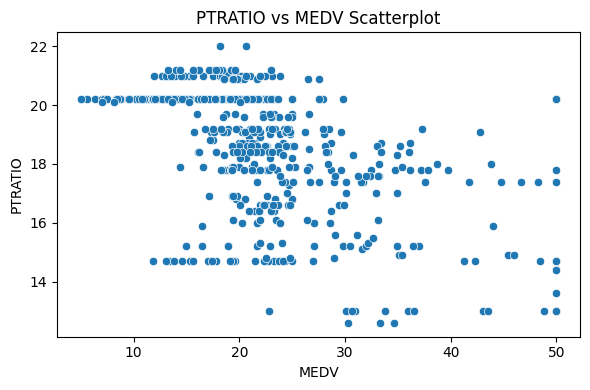

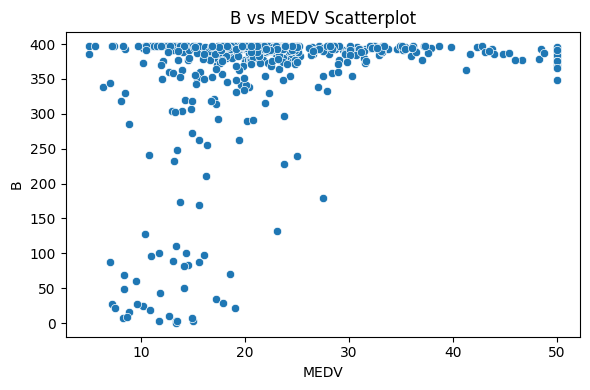

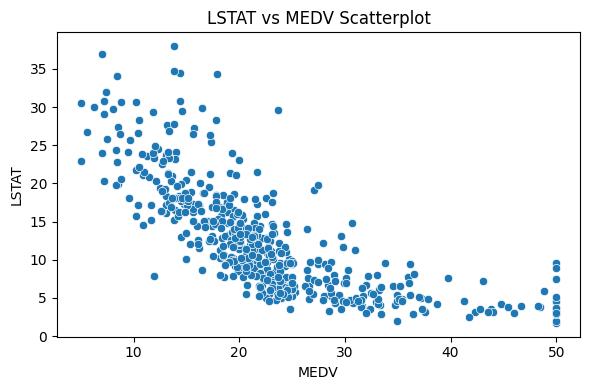

In [13]:
# Scatter plots of all features vs target
for i in (df.columns[:-1]):
  plt.figure(figsize=(6,4))
  sns.scatterplot(data=df,y=i,x=housing.target_names[0])
  plt.title(f"{i} vs MEDV Scatterplot")
  plt.tight_layout()
  plt.show()

Distribution of target

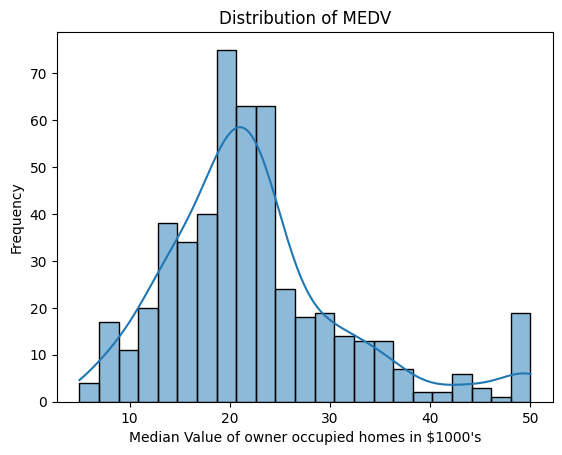

In [14]:
# Distribution using histogram
sns.histplot(data=df['MEDV'],kde=True)
plt.title("Distribution of MEDV")
plt.xlabel("Median Value of owner occupied homes in $1000's")
plt.ylabel("Frequency")
plt.show()

# Scaling and Splitting the data

In [15]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

Splitting the dataset into training and test dataset

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
# reset the old indices
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

Scaling the data (using MinMaxScaler)

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Implementing KNN regressor from scratch

In [19]:
def euclidean_distance(x,y):
  return np.sqrt(np.sum((x-y)**2))

def manhattan_distance(x,y):
  return np.sum(np.abs(x - y))

def cosine_distance(x,y):
  cosine_similarity = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
  return (1 - cosine_similarity)

In [20]:
class KNN:
  def __init__(self, k=3, distance_metric='euclidean'):
    self.k = k
    self.distance_metric = distance_metric

  def fit_knn(self, X_train, y_train):
    self.X_train = X_train
    self.y_train = y_train

  def _compute_distance(self, x):
    if self.distance_metric == 'euclidean':
      distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
    elif self.distance_metric == 'manhattan':
      distances = [manhattan_distance(x, x_train) for x_train in self.X_train]
    elif self.distance_metric == 'cosine':
      distances = [cosine_distance(x, x_train) for x_train in self.X_train]
    else:
      raise ValueError("Unsupported distance metric")
    return distances

  def predict_knn(self, X_test):
    predictions = []
    for x in X_test:
      distances = self._compute_distance(x)
      k_indices = np.argsort(distances)[:self.k]
      k_nearest_values = [self.y_train[i] for i in k_indices]
      prediction = np.average(k_nearest_values)
      predictions.append(prediction)
    return predictions


In [21]:
k = [i for i in range(3,15,2)]
distance_metric_choices = ['euclidean', 'manhattan', 'cosine']

In [22]:
# storing the r2 scores for different values of k and distance_metrics
combinations = []
for i in k:
  for j in distance_metric_choices:
    knn = KNN(k=i, distance_metric=j)
    knn.fit_knn(X_train_scaled, y_train)

    y_test_pred = knn.predict_knn(X_test_scaled)
    r2_score_scratch = r2_score(y_test, y_test_pred)
    combinations.append({
        'k': i,
        'metric':j,
        'r2_score':r2_score_scratch
    })

In [23]:
print(combinations)

[{'k': 3, 'metric': 'euclidean', 'r2_score': 0.824358474890345}, {'k': 3, 'metric': 'manhattan', 'r2_score': 0.8470192093295852}, {'k': 3, 'metric': 'cosine', 'r2_score': 0.8232717317049767}, {'k': 5, 'metric': 'euclidean', 'r2_score': 0.8234459492934849}, {'k': 5, 'metric': 'manhattan', 'r2_score': 0.8158196859125904}, {'k': 5, 'metric': 'cosine', 'r2_score': 0.8205346837287408}, {'k': 7, 'metric': 'euclidean', 'r2_score': 0.8135383313590103}, {'k': 7, 'metric': 'manhattan', 'r2_score': 0.8179218306083345}, {'k': 7, 'metric': 'cosine', 'r2_score': 0.8069128945357562}, {'k': 9, 'metric': 'euclidean', 'r2_score': 0.7704931553367631}, {'k': 9, 'metric': 'manhattan', 'r2_score': 0.8033678464012932}, {'k': 9, 'metric': 'cosine', 'r2_score': 0.7653275931753778}, {'k': 11, 'metric': 'euclidean', 'r2_score': 0.733870273886972}, {'k': 11, 'metric': 'manhattan', 'r2_score': 0.7782510508441127}, {'k': 11, 'metric': 'cosine', 'r2_score': 0.7367083260412592}, {'k': 13, 'metric': 'euclidean', 'r2_s

In [24]:
results_df = pd.DataFrame(combinations)

In [25]:
print(results_df)

     k     metric  r2_score
0    3  euclidean  0.824358
1    3  manhattan  0.847019
2    3     cosine  0.823272
3    5  euclidean  0.823446
4    5  manhattan  0.815820
5    5     cosine  0.820535
6    7  euclidean  0.813538
7    7  manhattan  0.817922
8    7     cosine  0.806913
9    9  euclidean  0.770493
10   9  manhattan  0.803368
11   9     cosine  0.765328
12  11  euclidean  0.733870
13  11  manhattan  0.778251
14  11     cosine  0.736708
15  13  euclidean  0.706929
16  13  manhattan  0.758168
17  13     cosine  0.703134


In [26]:
results_df.sort_values(by='r2_score',ascending=False)

,k,metric,r2_score
1,3,manhattan,0.847019
0,3,euclidean,0.824358
3,5,euclidean,0.823446
2,3,cosine,0.823272
5,5,cosine,0.820535
7,7,manhattan,0.817922
4,5,manhattan,0.815820
6,7,euclidean,0.813538
8,7,cosine,0.806913
10,9,manhattan,0.803368


From above, we find k=3 for Manhattan distance metric provided the best R2 score.

# Compare with scikit learn Simple KNN

In [27]:
regressor = KNeighborsRegressor(n_neighbors=3,metric='manhattan',algorithm="brute",weights="uniform")
regressor.fit(X_train_scaled, y_train)

KNeighborsRegressor(algorithm='brute', metric='manhattan', n_neighbors=3)

In [28]:
y_pred_sklearn = regressor.predict(X_test_scaled)

In [29]:
r2_score_sklearn = r2_score(y_test, y_pred_sklearn)

In [30]:
print(r2_score_sklearn)

0.8470192093295852


# Weighted KNN Regressor from scratch

In [31]:
class weighted_KNN:
  def __init__(self, k=3, distance_metric='euclidean'):
    self.k = k
    self.distance_metric = distance_metric

  def fit_knn(self, X_train, y_train):
    self.X_train = X_train
    self.y_train = y_train

  def _compute_weights(self, x):
    epsilon = 1e-5
    if self.distance_metric == 'euclidean':
      weights = [(1/(euclidean_distance(x, x_train) + epsilon)) for x_train in self.X_train]
    elif self.distance_metric == 'manhattan':
      weights = [(1/(manhattan_distance(x, x_train) + epsilon)) for x_train in self.X_train]
    elif self.distance_metric == 'cosine':
      weights = [(1/(cosine_distance(x, x_train) + epsilon)) for x_train in self.X_train]
    else:
      raise ValueError("Unsupported distance metric")
    return weights

  def predict_knn(self, X_test):
    predictions = []
    for x in X_test:
      weights = self._compute_weights(x)
      sorted_indices = np.argsort(weights)[::-1]
      k_indices = sorted_indices[:self.k]
      k_nearest_values = [self.y_train[i] for i in k_indices]
      weights_for_k_nearest = [weights[i] for i in k_indices]
      prediction = np.average(k_nearest_values, weights=weights_for_k_nearest)
      predictions.append(prediction)
    return predictions


In [32]:
# storing different R2 score values for weighted knn implementation for different k and distance metrics
weighted_all = []
for i in k:
  for j in distance_metric_choices:
    weighted_knn = weighted_KNN(k=i, distance_metric=j)
    weighted_knn.fit_knn(X_train_scaled, y_train)

    y_test_pred_weighted_scratch = weighted_knn.predict_knn(X_test_scaled)
    r2_score_scratch_weighted = r2_score(y_test, y_test_pred_weighted_scratch)
    weighted_all.append({
        'k': i,
        'metric':j,
        'r2_score':r2_score_scratch_weighted
    })

In [33]:
weighted_results_df = pd.DataFrame(weighted_all)

In [34]:
weighted_results_df.sort_values(by='r2_score',ascending=False)

,k,metric,r2_score
5,5,cosine,0.860707
8,7,cosine,0.859195
1,3,manhattan,0.857376
2,3,cosine,0.848649
3,5,euclidean,0.847049
7,7,manhattan,0.843103
11,9,cosine,0.840056
0,3,euclidean,0.839259
6,7,euclidean,0.838622
4,5,manhattan,0.837503


Here, best k = 5 for cosine metric

# Compare with Scikit learn Weighted KNN

In [35]:
regressor = KNeighborsRegressor(n_neighbors=5,metric='cosine',algorithm="brute",weights="distance")
regressor.fit(X_train_scaled, y_train)

KNeighborsRegressor(algorithm='brute', metric='cosine', weights='distance')

In [36]:
y_pred_sklearn = regressor.predict(X_test_scaled)

In [37]:
r2_score_sklearn = r2_score(y_test, y_pred_sklearn)

In [38]:
print(r2_score_sklearn)

0.8607469782389073


# Reporting and Visualization

Line chart for R2 score for Simple KNN and Weighted KNN implementation from scratch

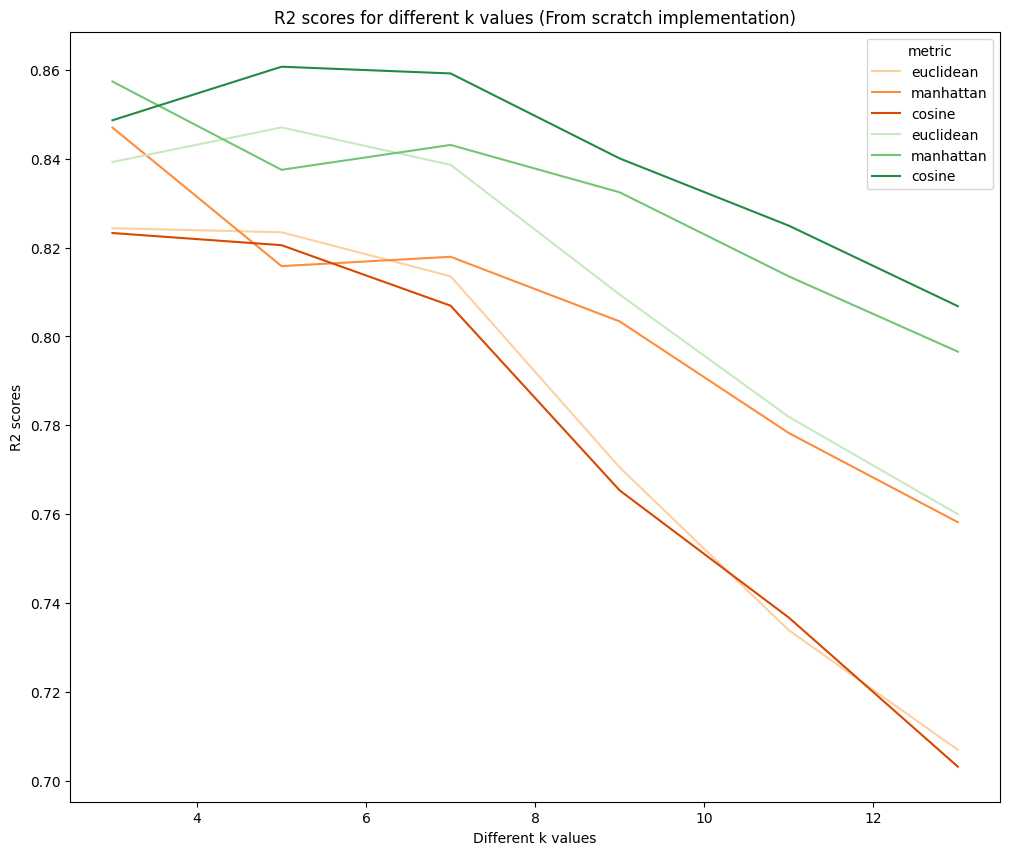

In [39]:
plt.figure(figsize=(12,10))
sns.lineplot(data=results_df,x="k",hue="metric",y="r2_score",palette="Oranges")
sns.lineplot(data=weighted_results_df,x="k",hue="metric",y="r2_score",palette="Greens")

plt.title("R2 scores for different k values (From scratch implementation)")
plt.xlabel("Different k values")
plt.ylabel("R2 scores")
plt.show()

Sklearn R2 scores plots

In [40]:
combined_sklearn = []
for i in k:
  for j in distance_metric_choices:
    knn = KNeighborsRegressor(n_neighbors=i, metric=j, weights="uniform")
    knn.fit(X_train_scaled, y_train)

    y_test_pred = knn.predict(X_test_scaled)
    r2_score_sklearn = r2_score(y_test, y_test_pred)
    combined_sklearn.append({
        'k': i,
        'metric':j,
        'r2_score':r2_score_sklearn
    })

In [41]:
results_sklearn_df = pd.DataFrame(combined_sklearn)

In [42]:
print(results_sklearn_df)

     k     metric  r2_score
0    3  euclidean  0.824358
1    3  manhattan  0.847019
2    3     cosine  0.823272
3    5  euclidean  0.823446
4    5  manhattan  0.815820
5    5     cosine  0.820535
6    7  euclidean  0.813538
7    7  manhattan  0.817922
8    7     cosine  0.806913
9    9  euclidean  0.770493
10   9  manhattan  0.803368
11   9     cosine  0.765328
12  11  euclidean  0.733870
13  11  manhattan  0.778251
14  11     cosine  0.736708
15  13  euclidean  0.706929
16  13  manhattan  0.758168
17  13     cosine  0.703134


In [43]:
combined_sklearn_weighted = []
for i in k:
  for j in distance_metric_choices:
    knn = KNeighborsRegressor(n_neighbors=i, metric=j, weights="distance")
    knn.fit(X_train_scaled, y_train)

    y_test_pred = knn.predict(X_test_scaled)
    r2_score_sklearn_weighted = r2_score(y_test, y_test_pred)
    combined_sklearn_weighted.append({
        'k': i,
        'metric':j,
        'r2_score':r2_score_sklearn_weighted
    })

In [44]:
results_weighted_sklearn_df = pd.DataFrame(combined_sklearn_weighted)

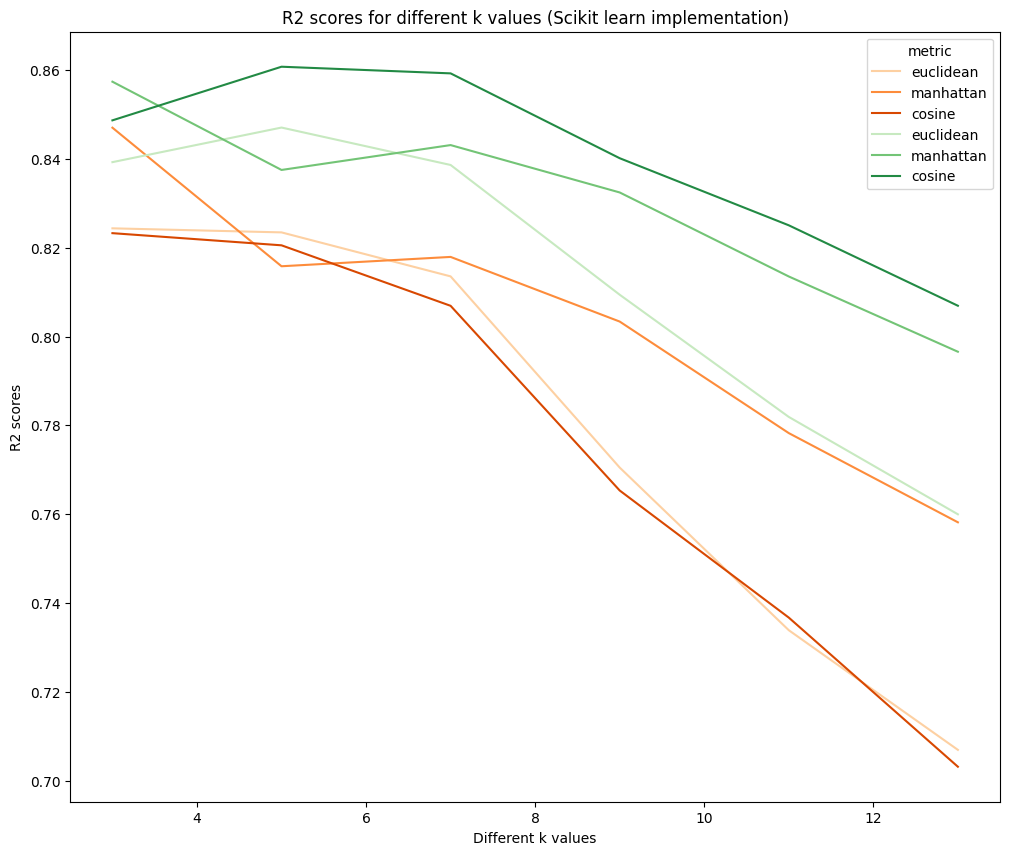

In [45]:
plt.figure(figsize=(12,10))
sns.lineplot(data=results_sklearn_df,x="k",hue="metric",y="r2_score",palette="Oranges")
sns.lineplot(data=results_weighted_sklearn_df,x="k",hue="metric",y="r2_score",palette="Greens")

plt.title("R2 scores for different k values (Scikit learn implementation)")
plt.xlabel("Different k values")
plt.ylabel("R2 scores")
plt.show()

Plotting the scatter plots of the actual and predicted datapoints for the best combination

For uniform KNN

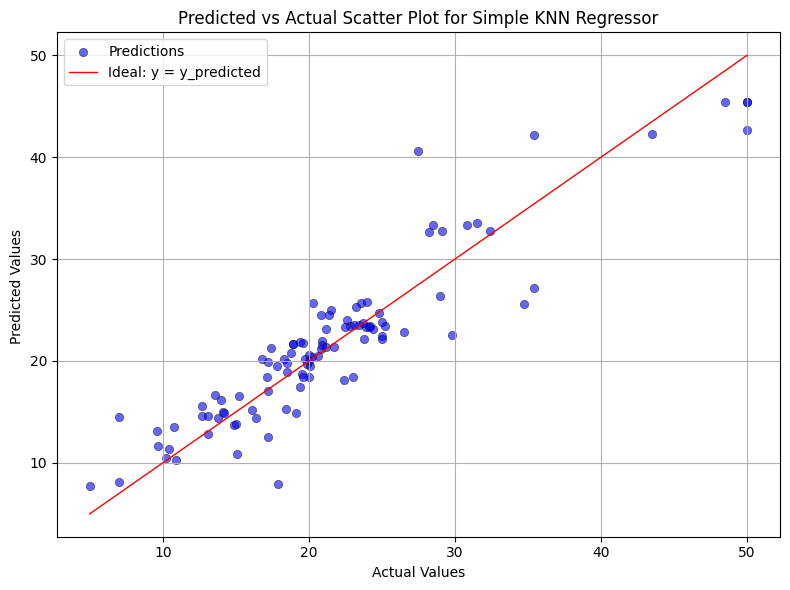

In [46]:
knn = KNN(k=3, distance_metric='manhattan')
knn.fit_knn(X_train_scaled, y_train)

plt.figure(figsize=(8, 6))

# Scatter actual vs predicted
sns.scatterplot(x=y_test, y=knn.predict_knn(X_test_scaled), color='blue', alpha=0.6, edgecolor='k', label='Predictions')

# Ideal line plot
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='-', linewidth=1, label='Ideal: y = y_predicted')

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values ")
plt.title("Predicted vs Actual Scatter Plot for Simple KNN Regressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


For weighted KNN

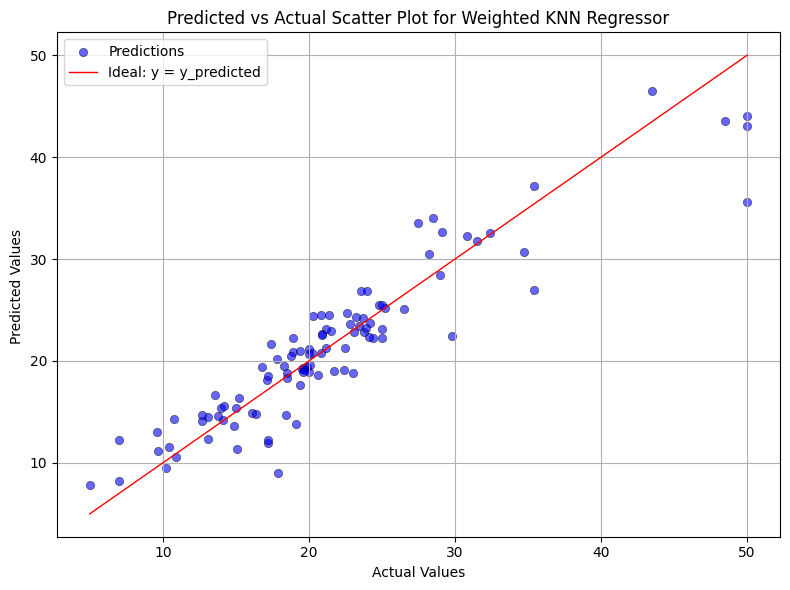

In [47]:
weighted_knn = weighted_KNN(k=5, distance_metric='cosine')
weighted_knn.fit_knn(X_train_scaled, y_train)

plt.figure(figsize=(8, 6))

# Scatter actual vs predicted
sns.scatterplot(x=y_test, y=weighted_knn.predict_knn(X_test_scaled), color='blue', alpha=0.6, edgecolor='k', label='Predictions')

# Add reference diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='-', linewidth=1, label='Ideal: y = y_predicted')

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values ")
plt.title("Predicted vs Actual Scatter Plot for Weighted KNN Regressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Summary

In case of the simple KNN regressor, k = 3, distance_metric='manhattan' performed the best.<br>
On the other hand, for the distance weighted KNN regressor, k = 5, distance_metric = 'cosine' performed the best.

In [48]:
knn = KNN(k=3, distance_metric='manhattan')
knn.fit_knn(X_train_scaled, y_train)

In [49]:
regressor = KNeighborsRegressor(n_neighbors=3,metric='manhattan',algorithm="brute",weights="uniform")
regressor.fit(X_train_scaled, y_train)

KNeighborsRegressor(algorithm='brute', metric='manhattan', n_neighbors=3)

In [50]:
import time
start = time.time()
knn.predict_knn(X_test_scaled)
scratch_time = time.time() - start
print(f"Time taken for the implementation of simple KNN regressor from scratch: {scratch_time} seconds.")

start_lib = time.time()
regressor.predict(X_test_scaled)
lib_time = time.time() - start_lib
print(f"Time taken for the implementation of KNN regressor from sklearn library: {lib_time} seconds.")

Time taken for the implementation of simple KNN regressor from scratch: 0.20107722282409668 seconds.
Time taken for the implementation of KNN regressor from sklearn library: 0.0019414424896240234 seconds.


In [51]:
weighted_knn = weighted_KNN(k=5, distance_metric='cosine')
weighted_knn.fit_knn(X_train_scaled, y_train)

In [52]:
weighted_regressor = KNeighborsRegressor(n_neighbors=5, metric='cosine',algorithm='brute',weights='distance')
weighted_regressor.fit(X_train_scaled, y_train)

KNeighborsRegressor(algorithm='brute', metric='cosine', weights='distance')

In [53]:
import time
start = time.time()
weighted_knn.predict_knn(X_test_scaled)
scratch_time = time.time() - start
print(f"Time taken for the implementation of weighted KNN regressor from scratch: {scratch_time} seconds.")

start_lib = time.time()
weighted_regressor.predict(X_test_scaled)
lib_time = time.time() - start_lib
print(f"Time taken for the implementation of weighted KNN regressor from sklearn library: {lib_time} seconds.")

Time taken for the implementation of weighted KNN regressor from scratch: 0.3752319812774658 seconds.
Time taken for the implementation of weighted KNN regressor from sklearn library: 0.0043489933013916016 seconds.


The R2 score for both implementation from scratch and using sklearn is same, but while comparing time, we find the library implementation to be faster.

**Observations on distance metrics:**
<br>In simple KNN regressor
*   Manhattan distance (for k = 3) achieved the highest R2 score
*   Euclidean distance followed Manhattan distance and was high for lower values of k.
*   Cosine distance gave lower R2 scores than the other two metrics in case of simple KNN regressor.




In weighted KNN regressor
*   The best R2 score was achieved using k=5 for the cosine distance metric.
*   Even though the cosine distance gave the lowest R2 scores in simple KNN regressor, when closer neighbours are given more weight, cosine distance gave the best R2 score.





Thus, k and the distance metrics must be tuned to get the best results.